In [1]:
import polars as pl
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import os

load_dotenv(".env")

True

## Active

In [ ]:
from src.pipelines.simple_time_correlation import SimpleTimeCorrelationActive
from src.hyperparameter_search.sliding_window_search import SlidingWindowSearch

lazy_frame = pl.scan_parquet("data/raw/active_alarms_prod.parquet")
results = SlidingWindowSearch.search(SimpleTimeCorrelationActive, lazy_frame, range(5,121,5), n_workers=5)

Avaliando janelas (SimpleTimeCorrelationActive) | workers=5 | batch=4,000,000:  58%|█████▊    | 14/24 [00:35<00:23,  2.39s/it, última=60s, erros=0]

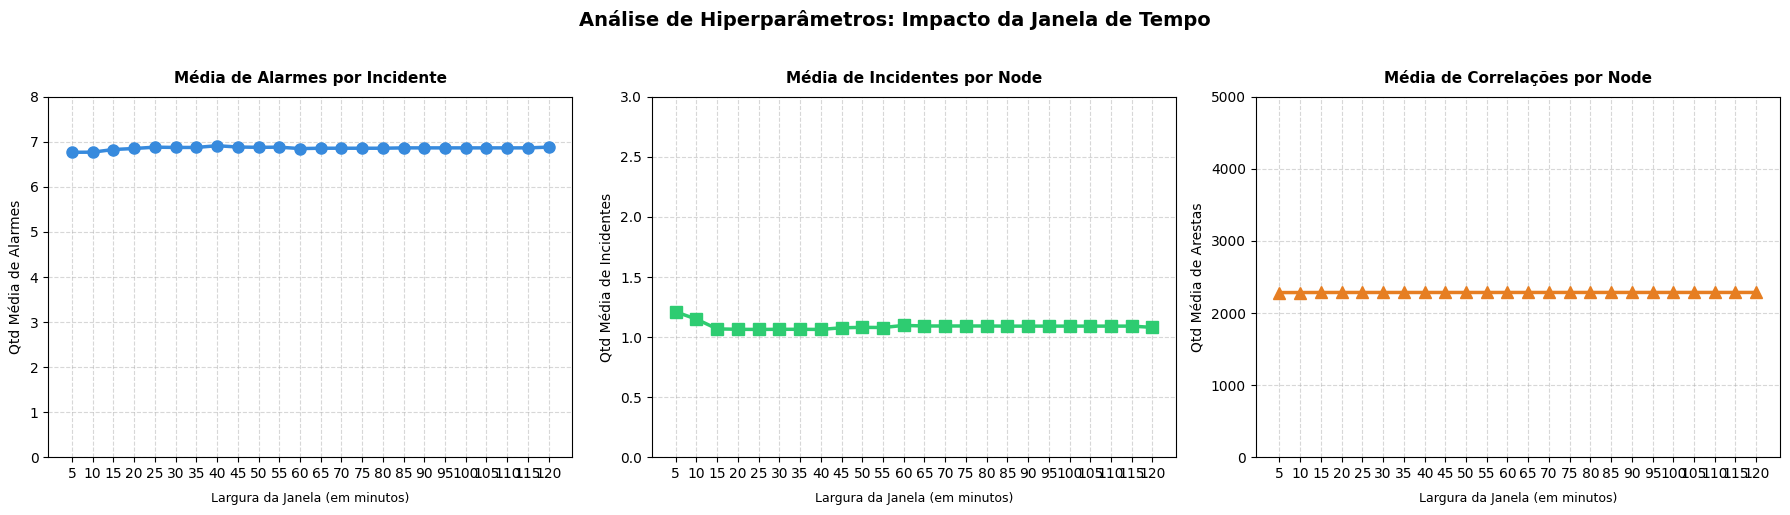

In [5]:
windows = sorted(results.keys())

medias_alarmes_incidente = []
medias_incidentes_node = []
medias_correlacoes_node = []

for w in windows:
    summary_df, metricas = results[w]
    medias_alarmes_incidente.append(metricas["media_alarmes_por_incidente"][0])
    medias_incidentes_node.append(metricas["media_incidentes_por_node"][0])
    medias_correlacoes_node.append(metricas["media_correlacoes_por_node"][0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(windows, medias_alarmes_incidente, marker='o', linestyle='-', color='#378ADD', linewidth=2.5, markersize=8)
axes[0].set_title("Média de Alarmes por Incidente", fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel("Qtd Média de Alarmes")
axes[0].set_ylim(top=8)

axes[1].plot(windows, medias_incidentes_node, marker='s', linestyle='-', color='#2ECC71', linewidth=2.5, markersize=8)
axes[1].set_title("Média de Incidentes por Node", fontsize=11, fontweight='bold', pad=10)
axes[1].set_ylabel("Qtd Média de Incidentes")
axes[1].set_ylim(top=3)

axes[2].plot(windows, medias_correlacoes_node, marker='^', linestyle='-', color='#E67E22', linewidth=2.5, markersize=8)
axes[2].set_title("Média de Correlações por Node", fontsize=11, fontweight='bold', pad=10)
axes[2].set_ylabel("Qtd Média de Arestas")
axes[2].set_ylim(top=5000)

for ax in axes:
    ax.set_xlabel("Largura da Janela (em minutos)", fontsize=9, labelpad=8)
    ax.set_ylim(bottom=0)
    ax.set_xticks(windows)
    ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Análise de Hiperparâmetros: Impacto da Janela de Tempo", fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## History

In [ ]:
from src.pipelines.simple_time_correlation import SimpleTimeCorrelationHistory
from src.hyperparameter_search.sliding_window_search import SlidingWindowSearch


lazy_frame = pl.scan_parquet("data/raw/alarm_history_dump.parquet")
results = SlidingWindowSearch.search(SimpleTimeCorrelationHistory, lazy_frame, range(5,121,5), n_workers=5)

Tamanho de data (Polars): 35319.9 MB
